# 06 - Evaluate GaitTR CE+Triplet Fixed Recommended Version

This notebook evaluates the new CE+Triplet trained GaitTR checkpoint.

Default checkpoint:

```text
/media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaittr_LT_ce_triplet_last.pth
```

It performs:

```text
1. checkpoint loading with classifier-key filtering if needed
2. dtype-safe gallery/probe CSV loading
3. deterministic embedding extraction
4. embedding collapse diagnostics
5. Rank-1 and Rank-5 evaluation
6. identical-view exclusion for CASIA-B protocol
7. per-view result table
8. failure-case export
9. plots and metadata saving
```

In [1]:
# ============================================================
# CELL 1 - Imports, config, paths
# ============================================================

from pathlib import Path
import json
import time
import gc

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

EXP_DIR = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0")
SPLIT_NAME = "LT"

SPLIT_DIR = EXP_DIR / "data" / "splits"
CHECKPOINT_DIR = EXP_DIR / "checkpoints"
RESULT_DIR = EXP_DIR / "results"
PLOT_DIR = RESULT_DIR / "plots"
for d in [RESULT_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Recommended first checkpoint to evaluate.
#CHECKPOINT_PATH = CHECKPOINT_DIR / "gaittr_LT_ce_triplet_last.pth"

# Optional comparisons after first run:
# CHECKPOINT_PATH = CHECKPOINT_DIR / "gaittr_LT_ce_triplet_best_loss.pth"
# CHECKPOINT_PATH = CHECKPOINT_DIR / "gaittr_LT_ce_triplet_best_train_acc.pth"
# Full checkpoint also works because classifier keys are filtered:
CHECKPOINT_PATH = CHECKPOINT_DIR / "gaittr_LT_ce_triplet_full_last.pth"

EVAL_MODE = "sliding"   # options: "sliding", "center", "full"
SEQ_LEN = 60
STRIDE = 30
BATCH_CLIPS = 128
EXCLUDE_IDENTICAL_VIEW = True
TOPK_VALUES = [1, 5]
PAIRWISE_DIAG_N = 300
SAVE_EMBEDDINGS = True
USE_EVAL_AMP = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 80)
print("GaitTR CE+Triplet Evaluation Notebook")
print("=" * 80)
print("EXP_DIR        :", EXP_DIR)
print("SPLIT_NAME     :", SPLIT_NAME)
print("CHECKPOINT_PATH:", CHECKPOINT_PATH)
print("EVAL_MODE      :", EVAL_MODE)
print("EXCLUDE SAME VIEW:", EXCLUDE_IDENTICAL_VIEW)
print("Device         :", device)
if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))
print("=" * 80)

assert CHECKPOINT_PATH.exists(), f"Checkpoint not found: {CHECKPOINT_PATH}"

GaitTR CE+Triplet Evaluation Notebook
EXP_DIR        : /media/wadud/DriveUbuntu/GaitRecognition 2.0
SPLIT_NAME     : LT
CHECKPOINT_PATH: /media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaittr_LT_ce_triplet_full_last.pth
EVAL_MODE      : sliding
EXCLUDE SAME VIEW: True
Device         : cuda
GPU            : NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
# ============================================================
# CELL 2 - Feature builder
# ============================================================

COCO_PARENTS = np.array([
    0, 0, 0, 1, 2,
    0, 0, 5, 6, 7, 8,
    5, 6, 11, 12, 13, 14
], dtype=np.int64)

def crop_or_pad_sequence(X, seq_len=60, random_crop=False):
    T = X.shape[0]
    if T == seq_len:
        return X
    if T > seq_len:
        start = np.random.randint(0, T - seq_len + 1) if random_crop else max(0, (T - seq_len) // 2)
        return X[start:start + seq_len]
    pad_len = seq_len - T
    pad = np.repeat(X[-1:], pad_len, axis=0)
    return np.concatenate([X, pad], axis=0)

def make_sliding_clips(X, clip_len=60, stride=30):
    T = X.shape[0]
    if T <= clip_len:
        return [crop_or_pad_sequence(X, clip_len, random_crop=False)]
    clips = []
    for start in range(0, T - clip_len + 1, stride):
        clips.append(X[start:start + clip_len])
    last_start = T - clip_len
    if last_start > 0:
        tail_clip = X[last_start:last_start + clip_len]
        if len(clips) == 0 or not np.array_equal(clips[-1], tail_clip):
            clips.append(tail_clip)
    return clips

def build_gaittr_features(X):
    X = X.astype(np.float32)
    assert X.ndim == 3 and X.shape[1:] == (17, 2), f"Bad skeleton shape: {X.shape}"

    joint = X.copy()
    nose = X[:, 0:1, :]
    joint_rel = X - nose

    v1 = np.zeros_like(X)
    v1[:-1] = X[1:] - X[:-1]

    v2 = np.zeros_like(X)
    v2[:-2] = X[2:] - X[:-2]

    bone = X - X[:, COCO_PARENTS, :]

    feat = np.concatenate([joint, joint_rel, v1, v2, bone], axis=-1)
    feat = feat.transpose(2, 0, 1).astype(np.float32)
    return feat

In [3]:
# ============================================================
# CELL 3 - Evaluation backbone model
# Must match training backbone, without classifier head
# ============================================================

class TCN(nn.Module):
    def __init__(self, in_channels, out_channels, temporal_kernel=9, dropout=0.1):
        super().__init__()
        pad = temporal_kernel // 2
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=(temporal_kernel, 1), padding=(pad, 0), bias=False),
            nn.Dropout(dropout),
            nn.Mish(),
            nn.BatchNorm2d(out_channels),
        )
    def forward(self, x):
        return self.net(x)

class SpatialTransformer(nn.Module):
    def __init__(self, channels, num_heads=8, dropout=0.1):
        super().__init__()
        assert channels % num_heads == 0
        self.norm = nn.LayerNorm(channels)
        self.attn = nn.MultiheadAttention(channels, num_heads, dropout=dropout, batch_first=True)
        self.proj = nn.Linear(channels, channels)
        self.act = nn.Mish()
        self.bn = nn.BatchNorm2d(channels)
    def forward(self, x):
        B, C, T, V = x.shape
        tokens = x.permute(0, 2, 3, 1).contiguous().view(B * T, V, C)
        tokens = self.norm(tokens)
        out, _ = self.attn(tokens, tokens, tokens, need_weights=False)
        out = self.proj(out)
        out = out.view(B, T, V, C).permute(0, 3, 1, 2).contiguous()
        out = self.act(out)
        out = self.bn(out)
        return out

class TCNSTBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_heads=8, temporal_kernel=9, dropout=0.1):
        super().__init__()
        self.tcn = TCN(in_channels, out_channels, temporal_kernel, dropout)
        self.st = SpatialTransformer(out_channels, num_heads, dropout)
        if in_channels == out_channels:
            self.residual = nn.Identity()
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.Mish(),
                nn.BatchNorm2d(out_channels),
            )
    def forward(self, x):
        return self.st(self.tcn(x)) + self.residual(x)

class GaitTRBackbone(nn.Module):
    def __init__(self, in_channels=10, embedding_dim=128, channels=(64, 64, 128, 256), num_heads=8, temporal_kernel=9, dropout=0.1):
        super().__init__()
        self.data_bn = nn.BatchNorm2d(in_channels)
        blocks = []
        prev = in_channels
        for ch in channels:
            blocks.append(TCNSTBlock(prev, ch, num_heads, temporal_kernel, dropout))
            prev = ch
        self.blocks = nn.Sequential(*blocks)
        self.fc = nn.Linear(channels[-1], embedding_dim, bias=False)
    def forward(self, x):
        x = self.data_bn(x)
        x = self.blocks(x)
        x = x.mean(dim=(2, 3))
        emb = self.fc(x)
        emb = F.normalize(emb, p=2, dim=1)
        return emb

In [4]:
# ============================================================
# CELL 4 - Load checkpoint robustly
# Supports eval checkpoint and full CE+Triplet checkpoint
# ============================================================

def safe_torch_load(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

def filter_backbone_state_dict(state_dict):
    filtered = {}
    removed = []
    for k, v in state_dict.items():
        if k.startswith("classifier."):
            removed.append(k)
            continue
        filtered[k] = v
    return filtered, removed

ckpt = safe_torch_load(CHECKPOINT_PATH, map_location=device)
config = ckpt.get("config", {})

in_channels = int(config.get("in_channels", 10))
embedding_dim = int(config.get("embedding_dim", 128))
channels = tuple(config.get("channels", [64, 64, 128, 256]))
num_heads = int(config.get("num_heads", 8))
temporal_kernel = int(config.get("temporal_kernel", 9))
dropout = float(config.get("dropout", 0.1))

state_dict, removed_keys = filter_backbone_state_dict(ckpt["model"])

model = GaitTRBackbone(
    in_channels=in_channels,
    embedding_dim=embedding_dim,
    channels=channels,
    num_heads=num_heads,
    temporal_kernel=temporal_kernel,
    dropout=dropout,
).to(device)

missing_keys, unexpected_keys = model.load_state_dict(state_dict, strict=False)

if missing_keys:
    print("[WARNING] Missing keys:", missing_keys)
if unexpected_keys:
    print("[WARNING] Unexpected keys:", unexpected_keys)
if removed_keys:
    print(f"[INFO] Removed {len(removed_keys)} classifier keys from full checkpoint.")

model.eval()

RUN_TAG = CHECKPOINT_PATH.stem
RESULT_PREFIX = f"{SPLIT_NAME}_ce_triplet_{RUN_TAG}"

print("=" * 80)
print("Checkpoint loaded")
print("=" * 80)
print("checkpoint_type:", ckpt.get("checkpoint_type", "unknown"))
print("checkpoint     :", CHECKPOINT_PATH)
print("run_tag        :", RUN_TAG)
print("step           :", ckpt.get("step", "unknown"))
print("channels       :", channels)
print("embedding_dim  :", embedding_dim)
print("removed classifier keys:", len(removed_keys))
print("=" * 80)

# Forward sanity check
with torch.no_grad():
    dummy = torch.randn(2, 10, 60, 17).to(device)
    test_emb = model(dummy)
print("Test embedding shape:", test_emb.shape)
assert test_emb.shape == (2, embedding_dim)
del dummy, test_emb
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

[INFO] Removed 2 classifier keys from full checkpoint.
Checkpoint loaded
checkpoint_type: full_ce_triplet_with_classifier
checkpoint     : /media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaittr_LT_ce_triplet_full_last.pth
run_tag        : gaittr_LT_ce_triplet_full_last
step           : 30000
channels       : (64, 64, 128, 256)
embedding_dim  : 128
removed classifier keys: 2
Test embedding shape: torch.Size([2, 128])


In [5]:
# ============================================================
# CELL 5 - Load gallery/probe CSVs safely
# ============================================================

csv_dtype = {
    "pose_path": str,
    "subject": str,
    "condition": str,
    "seq": str,
    "view": str,
}

gallery_csv = SPLIT_DIR / f"gallery_{SPLIT_NAME}.csv"
probe_nm_csv = SPLIT_DIR / f"probe_{SPLIT_NAME}_nm.csv"
probe_bg_csv = SPLIT_DIR / f"probe_{SPLIT_NAME}_bg.csv"
probe_cl_csv = SPLIT_DIR / f"probe_{SPLIT_NAME}_cl.csv"

for p in [gallery_csv, probe_nm_csv, probe_bg_csv, probe_cl_csv]:
    assert p.exists(), f"Missing split file: {p}"

df_gallery = pd.read_csv(gallery_csv, dtype=csv_dtype)
df_probe_nm = pd.read_csv(probe_nm_csv, dtype=csv_dtype)
df_probe_bg = pd.read_csv(probe_bg_csv, dtype=csv_dtype)
df_probe_cl = pd.read_csv(probe_cl_csv, dtype=csv_dtype)

def check_split_df(df, name, expected_rows=None, expected_subjects=None):
    missing = [p for p in df["pose_path"].tolist() if not Path(p).exists()]
    print(f"{name}: rows={len(df)}, subjects={df['subject'].nunique()}, missing_paths={len(missing)}")
    if expected_rows is not None and len(df) != expected_rows:
        print(f"[WARNING] {name} expected {expected_rows} rows, found {len(df)}")
    if expected_subjects is not None and df["subject"].nunique() != expected_subjects:
        print(f"[WARNING] {name} expected {expected_subjects} subjects, found {df['subject'].nunique()}")
    if missing:
        print("First missing:", missing[0])
        raise FileNotFoundError(f"{name} has missing pose paths.")

check_split_df(df_gallery, "gallery", expected_rows=2200, expected_subjects=50)
check_split_df(df_probe_nm, "probe_nm", expected_rows=1100, expected_subjects=50)
check_split_df(df_probe_bg, "probe_bg", expected_rows=1100, expected_subjects=50)
check_split_df(df_probe_cl, "probe_cl", expected_rows=1100, expected_subjects=50)

display(df_gallery.head())

gallery: rows=2200, subjects=50, missing_paths=0
probe_nm: rows=1100, subjects=50, missing_paths=0
probe_bg: rows=1100, subjects=50, missing_paths=0
probe_cl: rows=1100, subjects=50, missing_paths=0


,pose_path,subject,condition,seq,view
0,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,000
1,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,018
2,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,036
3,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,054
4,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,072


In [6]:
# ============================================================
# CELL 6 - Embedding extraction
# ============================================================

def eval_autocast_context():
    if device.type == "cuda" and USE_EVAL_AMP:
        try:
            return torch.amp.autocast("cuda", enabled=True)
        except Exception:
            return torch.cuda.amp.autocast(enabled=True)
    try:
        return torch.amp.autocast("cuda", enabled=False)
    except Exception:
        return torch.cuda.amp.autocast(enabled=False)

@torch.no_grad()
def extract_video_embedding(pose_path):
    data = np.load(pose_path)
    X = data["keypoints_norm_filled"].astype(np.float32)

    if EVAL_MODE == "full":
        feat = build_gaittr_features(X)
        x = torch.from_numpy(feat).unsqueeze(0).float().to(device)
        with eval_autocast_context():
            emb = model(x)
        emb = emb.squeeze(0).float().cpu()
        return F.normalize(emb, p=2, dim=0)

    if EVAL_MODE == "center":
        X60 = crop_or_pad_sequence(X, seq_len=SEQ_LEN, random_crop=False)
        feat = build_gaittr_features(X60)
        x = torch.from_numpy(feat).unsqueeze(0).float().to(device)
        with eval_autocast_context():
            emb = model(x)
        emb = emb.squeeze(0).float().cpu()
        return F.normalize(emb, p=2, dim=0)

    if EVAL_MODE == "sliding":
        clips = make_sliding_clips(X, clip_len=SEQ_LEN, stride=STRIDE)
        feats = np.stack([build_gaittr_features(c) for c in clips], axis=0)
        embs = []
        for start in range(0, len(feats), BATCH_CLIPS):
            batch = torch.from_numpy(feats[start:start + BATCH_CLIPS]).float().to(device)
            with eval_autocast_context():
                emb = model(batch)
            embs.append(emb.float().cpu())
        embs = torch.cat(embs, dim=0)
        final_emb = embs.mean(dim=0)
        return F.normalize(final_emb, p=2, dim=0)

    raise ValueError(f"Unknown EVAL_MODE: {EVAL_MODE}")

def extract_embeddings_for_df(df, name):
    rows = []
    embeddings = []
    start_time = time.time()
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Extract {name}"):
        emb = extract_video_embedding(row["pose_path"])
        embeddings.append(emb)
        rows.append({
            "subject": str(row["subject"]),
            "condition": str(row["condition"]),
            "seq": str(row["seq"]),
            "view": str(row["view"]),
            "pose_path": str(row["pose_path"]),
        })
    meta_df = pd.DataFrame(rows)
    emb_tensor = torch.stack(embeddings, dim=0)
    elapsed = time.time() - start_time
    print(f"{name}: embeddings={tuple(emb_tensor.shape)}, elapsed_min={elapsed/60:.2f}")
    return meta_df, emb_tensor

In [7]:
# ============================================================
# CELL 7 - Extract and save embeddings
# ============================================================

gallery_meta, gallery_emb = extract_embeddings_for_df(df_gallery, "gallery")
probe_nm_meta, probe_nm_emb = extract_embeddings_for_df(df_probe_nm, "probe_nm")
probe_bg_meta, probe_bg_emb = extract_embeddings_for_df(df_probe_bg, "probe_bg")
probe_cl_meta, probe_cl_emb = extract_embeddings_for_df(df_probe_cl, "probe_cl")

print("Gallery emb:", gallery_emb.shape)
print("Probe NM   :", probe_nm_emb.shape)
print("Probe BG   :", probe_bg_emb.shape)
print("Probe CL   :", probe_cl_emb.shape)

if SAVE_EMBEDDINGS:
    payloads = {
        f"gallery_{RESULT_PREFIX}_embeddings.pt": {"meta": gallery_meta, "embeddings": gallery_emb, "checkpoint": str(CHECKPOINT_PATH), "eval_mode": EVAL_MODE},
        f"probe_{RESULT_PREFIX}_nm_embeddings.pt": {"meta": probe_nm_meta, "embeddings": probe_nm_emb, "checkpoint": str(CHECKPOINT_PATH), "eval_mode": EVAL_MODE},
        f"probe_{RESULT_PREFIX}_bg_embeddings.pt": {"meta": probe_bg_meta, "embeddings": probe_bg_emb, "checkpoint": str(CHECKPOINT_PATH), "eval_mode": EVAL_MODE},
        f"probe_{RESULT_PREFIX}_cl_embeddings.pt": {"meta": probe_cl_meta, "embeddings": probe_cl_emb, "checkpoint": str(CHECKPOINT_PATH), "eval_mode": EVAL_MODE},
        # Legacy names for existing analysis notebooks
        f"gallery_{SPLIT_NAME}_embeddings.pt": {"meta": gallery_meta, "embeddings": gallery_emb},
        f"probe_{SPLIT_NAME}_nm_embeddings.pt": {"meta": probe_nm_meta, "embeddings": probe_nm_emb},
        f"probe_{SPLIT_NAME}_bg_embeddings.pt": {"meta": probe_bg_meta, "embeddings": probe_bg_emb},
        f"probe_{SPLIT_NAME}_cl_embeddings.pt": {"meta": probe_cl_meta, "embeddings": probe_cl_emb},
    }
    for filename, payload in payloads.items():
        torch.save(payload, RESULT_DIR / filename)
    print("Saved embeddings to:", RESULT_DIR)

Extract gallery:   0%|          | 0/2200 [00:00<?, ?it/s]

gallery: embeddings=(2200, 128), elapsed_min=0.16


Extract probe_nm:   0%|          | 0/1100 [00:00<?, ?it/s]

probe_nm: embeddings=(1100, 128), elapsed_min=0.08


Extract probe_bg:   0%|          | 0/1100 [00:00<?, ?it/s]

probe_bg: embeddings=(1100, 128), elapsed_min=0.06


Extract probe_cl:   0%|          | 0/1100 [00:00<?, ?it/s]

probe_cl: embeddings=(1100, 128), elapsed_min=0.07
Gallery emb: torch.Size([2200, 128])
Probe NM   : torch.Size([1100, 128])
Probe BG   : torch.Size([1100, 128])
Probe CL   : torch.Size([1100, 128])
Saved embeddings to: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results


In [8]:
# ============================================================
# CELL 8 - Embedding diagnostics
# ============================================================

def embedding_diagnostics(name, emb, diag_n=300):
    emb = emb.float().cpu()
    norms = torch.norm(emb, p=2, dim=1)
    out = {
        "name": name,
        "num": int(emb.shape[0]),
        "dim": int(emb.shape[1]),
        "norm_mean": float(norms.mean().item()),
        "norm_min": float(norms.min().item()),
        "norm_max": float(norms.max().item()),
    }
    n = min(diag_n, emb.shape[0])
    if n >= 2:
        sub = emb[:n]
        dist = torch.cdist(sub, sub, p=2)
        mask = ~torch.eye(n, dtype=torch.bool)
        out.update({
            "pairwise_n": int(n),
            "pairwise_mean": float(dist[mask].mean().item()),
            "pairwise_min": float(dist[mask].min().item()),
            "pairwise_max": float(dist[mask].max().item()),
        })
    return out

df_diag = pd.DataFrame([
    embedding_diagnostics("gallery", gallery_emb, PAIRWISE_DIAG_N),
    embedding_diagnostics("probe_nm", probe_nm_emb, PAIRWISE_DIAG_N),
    embedding_diagnostics("probe_bg", probe_bg_emb, PAIRWISE_DIAG_N),
    embedding_diagnostics("probe_cl", probe_cl_emb, PAIRWISE_DIAG_N),
])

diag_tagged = RESULT_DIR / f"embedding_diagnostics_{RESULT_PREFIX}.csv"
diag_ce = RESULT_DIR / f"embedding_diagnostics_{SPLIT_NAME}_ce_triplet.csv"
diag_legacy = RESULT_DIR / f"embedding_diagnostics_{SPLIT_NAME}.csv"
for p in [diag_tagged, diag_ce, diag_legacy]:
    df_diag.to_csv(p, index=False)

display(df_diag)

pairwise = float(df_diag.loc[df_diag["name"] == "gallery", "pairwise_mean"].iloc[0])
if pairwise < 0.05:
    print("[DANGER] Embedding collapse likely: pairwise_mean is near zero.")
elif pairwise < 0.20:
    print("[WARNING] Pairwise distance is small. Check accuracy carefully.")
else:
    print("[OK] Embeddings have healthy non-zero spread.")

,name,num,dim,norm_mean,norm_min,norm_max,pairwise_n,pairwise_mean,pairwise_min,pairwise_max
0,gallery,2200,128,1.0,1.0,1.0,300,1.313844,0.305080,1.675032
1,probe_nm,1100,128,1.0,1.0,1.0,300,1.333530,0.315372,1.689009
2,probe_bg,1100,128,1.0,1.0,1.0,300,1.341206,0.305990,1.666255
3,probe_cl,1100,128,1.0,1.0,1.0,300,1.324136,0.349567,1.673065


[OK] Embeddings have healthy non-zero spread.


In [9]:
# ============================================================
# CELL 9 - Rank-k evaluation
# ============================================================

def evaluate_rankk_vectorized(gallery_meta, gallery_emb, probe_meta, probe_emb, condition_name, topk_values=(1, 5), exclude_identical_view=True):
    gallery_subjects = gallery_meta["subject"].astype(str).tolist()
    gallery_views = gallery_meta["view"].astype(str).tolist()
    probe_subjects = probe_meta["subject"].astype(str).tolist()
    probe_views = probe_meta["view"].astype(str).tolist()

    g_emb = gallery_emb.float().cpu()
    p_emb = probe_emb.float().cpu()
    dist = torch.cdist(p_emb, g_emb, p=2)

    if exclude_identical_view:
        for i, p_view in enumerate(probe_views):
            same_view_mask = torch.tensor([g_view == p_view for g_view in gallery_views], dtype=torch.bool)
            dist[i, same_view_mask] = float("inf")

    max_k = max(topk_values)
    topk_indices = torch.topk(dist, k=max_k, dim=1, largest=False).indices.tolist()

    correct_at_k = {k: 0 for k in topk_values}
    rows = []

    for i, idx_list in enumerate(topk_indices):
        true_subject = probe_subjects[i]
        pred_subjects = [gallery_subjects[j] for j in idx_list]
        pred_views = [gallery_views[j] for j in idx_list]
        pred_dists = [float(dist[i, j].item()) for j in idx_list]

        for k in topk_values:
            if true_subject in pred_subjects[:k]:
                correct_at_k[k] += 1

        rows.append({
            "condition": condition_name,
            "probe_index": i,
            "subject": true_subject,
            "view": probe_views[i],
            "seq": str(probe_meta.iloc[i]["seq"]),
            "pose_path": str(probe_meta.iloc[i]["pose_path"]),
            "pred_subject_rank1": pred_subjects[0],
            "pred_view_rank1": pred_views[0],
            "distance_rank1": pred_dists[0],
            "correct_rank1": int(pred_subjects[0] == true_subject),
            "pred_subjects_top5": "|".join(pred_subjects[:5]),
            "pred_views_top5": "|".join(pred_views[:5]),
            "distances_top5": "|".join([f"{d:.6f}" for d in pred_dists[:5]]),
            "correct_rank5": int(true_subject in pred_subjects[:5]),
        })

    df = pd.DataFrame(rows)
    summary = {f"rank{k}": correct_at_k[k] / len(df) if len(df) else 0.0 for k in topk_values}
    return summary, df

summary_nm, df_res_nm = evaluate_rankk_vectorized(gallery_meta, gallery_emb, probe_nm_meta, probe_nm_emb, "NM", TOPK_VALUES, EXCLUDE_IDENTICAL_VIEW)
summary_bg, df_res_bg = evaluate_rankk_vectorized(gallery_meta, gallery_emb, probe_bg_meta, probe_bg_emb, "BG", TOPK_VALUES, EXCLUDE_IDENTICAL_VIEW)
summary_cl, df_res_cl = evaluate_rankk_vectorized(gallery_meta, gallery_emb, probe_cl_meta, probe_cl_emb, "CL", TOPK_VALUES, EXCLUDE_IDENTICAL_VIEW)

df_all_results = pd.concat([df_res_nm, df_res_bg, df_res_cl], ignore_index=True)

summary_rows = []
for condition, summary, df_res in [("NM", summary_nm, df_res_nm), ("BG", summary_bg, df_res_bg), ("CL", summary_cl, df_res_cl)]:
    row = {"condition": condition, "num_probe": len(df_res)}
    for k in TOPK_VALUES:
        row[f"rank{k}"] = summary[f"rank{k}"]
        row[f"rank{k}_percent"] = summary[f"rank{k}"] * 100.0
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

print("=" * 80)
print("Rank-k Summary")
print("=" * 80)
for _, row in df_summary.iterrows():
    msg = f"{row['condition']}: " + ", ".join([f"Rank-{k}={row[f'rank{k}_percent']:.2f}%" for k in TOPK_VALUES])
    msg += f" ({int(row['num_probe'])} probes)"
    print(msg)
print("=" * 80)

,condition,num_probe,rank1,rank1_percent,rank5,rank5_percent
0,NM,1100,0.949091,94.909091,0.973636,97.363636
1,BG,1100,0.792727,79.272727,0.887273,88.727273
2,CL,1100,0.751818,75.181818,0.868182,86.818182


Rank-k Summary
NM: Rank-1=94.91%, Rank-5=97.36% (1100 probes)
BG: Rank-1=79.27%, Rank-5=88.73% (1100 probes)
CL: Rank-1=75.18%, Rank-5=86.82% (1100 probes)


In [10]:
# ============================================================
# CELL 10 - Per-view metrics
# ============================================================

per_view_rows = []
for (condition, view), sub in df_all_results.groupby(["condition", "view"]):
    row = {"condition": condition, "view": view, "num_probe": len(sub)}
    for k in TOPK_VALUES:
        col = f"correct_rank{k}"
        row[f"rank{k}"] = float(sub[col].mean())
        row[f"rank{k}_percent"] = float(sub[col].mean() * 100.0)
    per_view_rows.append(row)

df_per_view = pd.DataFrame(per_view_rows)
df_per_view["view_int"] = df_per_view["view"].astype(int)
df_per_view = df_per_view.sort_values(["condition", "view_int"]).drop(columns=["view_int"])

display(df_per_view.head(40))

,condition,view,num_probe,rank1,rank1_percent,rank5,rank5_percent
0,BG,000,100,0.74,74.0,0.86,86.0
1,BG,018,100,0.83,83.0,0.92,92.0
2,BG,036,100,0.86,86.0,0.90,90.0
3,BG,054,100,0.81,81.0,0.89,89.0
4,BG,072,100,0.77,77.0,0.89,89.0
5,BG,090,100,0.80,80.0,0.88,88.0
6,BG,108,100,0.80,80.0,0.87,87.0
7,BG,126,100,0.77,77.0,0.91,91.0
8,BG,144,100,0.82,82.0,0.88,88.0
9,BG,162,100,0.79,79.0,0.92,92.0


In [11]:
# ============================================================
# CELL 11 - Save CSV results and metadata
# ============================================================

summary_tagged = RESULT_DIR / f"rank_metrics_{RESULT_PREFIX}_summary.csv"
per_view_tagged = RESULT_DIR / f"rank_metrics_{RESULT_PREFIX}_per_view.csv"
all_results_tagged = RESULT_DIR / f"rank_metrics_{RESULT_PREFIX}_all_probe_results.csv"

summary_ce = RESULT_DIR / f"rank1_{SPLIT_NAME}_ce_triplet_summary.csv"
per_view_ce = RESULT_DIR / f"rank1_{SPLIT_NAME}_ce_triplet_per_view.csv"
all_results_ce = RESULT_DIR / f"rank1_{SPLIT_NAME}_ce_triplet_all_probe_results.csv"

summary_legacy = RESULT_DIR / f"rank1_{SPLIT_NAME}_summary.csv"
per_view_legacy = RESULT_DIR / f"rank1_{SPLIT_NAME}_per_view.csv"
all_results_legacy = RESULT_DIR / f"rank1_{SPLIT_NAME}_all_probe_results.csv"

for p in [summary_tagged, summary_ce, summary_legacy]:
    df_summary.to_csv(p, index=False)
for p in [per_view_tagged, per_view_ce, per_view_legacy]:
    df_per_view.to_csv(p, index=False)
for p in [all_results_tagged, all_results_ce, all_results_legacy]:
    df_all_results.to_csv(p, index=False)

metadata = {
    "checkpoint": str(CHECKPOINT_PATH),
    "checkpoint_type": ckpt.get("checkpoint_type", "unknown"),
    "run_tag": RUN_TAG,
    "result_prefix": RESULT_PREFIX,
    "split_name": SPLIT_NAME,
    "eval_mode": EVAL_MODE,
    "seq_len": SEQ_LEN,
    "stride": STRIDE,
    "exclude_identical_view": EXCLUDE_IDENTICAL_VIEW,
    "topk_values": TOPK_VALUES,
    "summary_tagged": str(summary_tagged),
    "per_view_tagged": str(per_view_tagged),
    "all_results_tagged": str(all_results_tagged),
    "embedding_diagnostics": str(diag_tagged),
}
metadata_path = RESULT_DIR / f"evaluation_metadata_{RESULT_PREFIX}.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved tagged summary    :", summary_tagged)
print("Saved CE summary        :", summary_ce)
print("Saved legacy summary    :", summary_legacy)
print("Saved tagged per-view   :", per_view_tagged)
print("Saved tagged all results:", all_results_tagged)
print("Saved metadata          :", metadata_path)

Saved tagged summary    : /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/rank_metrics_LT_ce_triplet_gaittr_LT_ce_triplet_full_last_summary.csv
Saved CE summary        : /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/rank1_LT_ce_triplet_summary.csv
Saved legacy summary    : /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/rank1_LT_summary.csv
Saved tagged per-view   : /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/rank_metrics_LT_ce_triplet_gaittr_LT_ce_triplet_full_last_per_view.csv
Saved tagged all results: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/rank_metrics_LT_ce_triplet_gaittr_LT_ce_triplet_full_last_all_probe_results.csv
Saved metadata          : /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/evaluation_metadata_LT_ce_triplet_gaittr_LT_ce_triplet_full_last.json


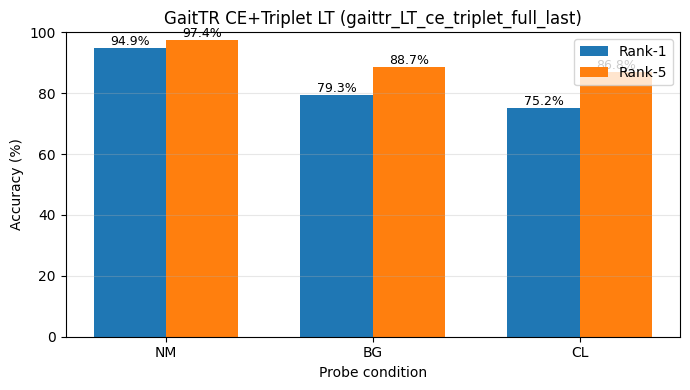

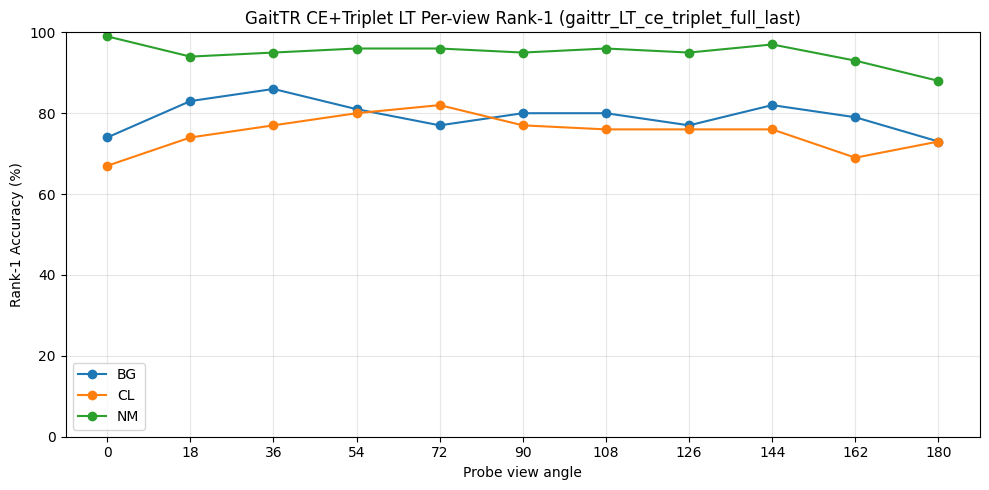

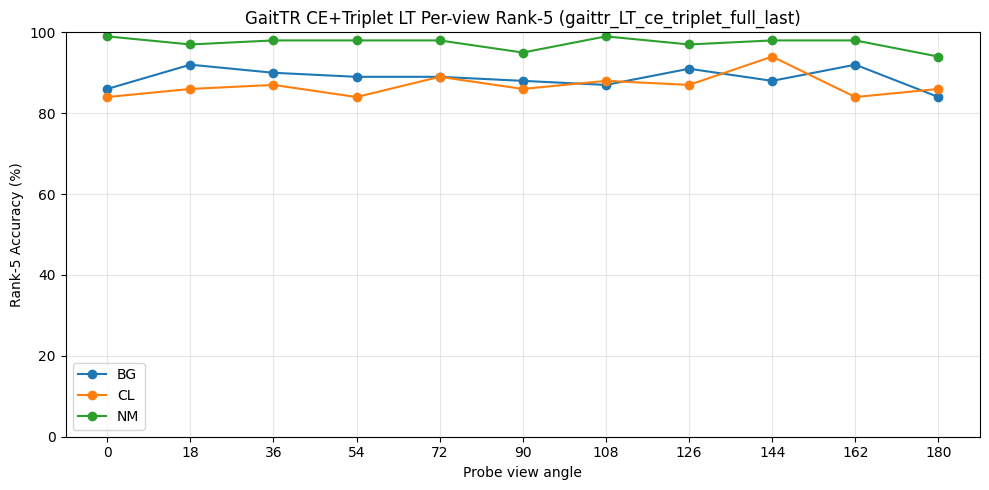

Saved plot: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/plots/rank_metrics_LT_ce_triplet_gaittr_LT_ce_triplet_full_last_summary_bar.png
Saved plot: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/plots/rank1_LT_ce_triplet_gaittr_LT_ce_triplet_full_last_per_view.png
Saved plot: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/plots/rank5_LT_ce_triplet_gaittr_LT_ce_triplet_full_last_per_view.png


In [12]:
# ============================================================
# CELL 12 - Plots
# ============================================================

x = np.arange(len(df_summary["condition"]))
width = 0.35

plt.figure(figsize=(7, 4))
if 1 in TOPK_VALUES:
    plt.bar(x - width/2, df_summary["rank1_percent"], width, label="Rank-1")
if 5 in TOPK_VALUES:
    plt.bar(x + width/2, df_summary["rank5_percent"], width, label="Rank-5")

plt.xticks(x, df_summary["condition"])
plt.ylabel("Accuracy (%)")
plt.xlabel("Probe condition")
plt.title(f"GaitTR CE+Triplet {SPLIT_NAME} ({RUN_TAG})")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.legend()
for i, row in df_summary.iterrows():
    if 1 in TOPK_VALUES:
        plt.text(i - width/2, row["rank1_percent"] + 1, f"{row['rank1_percent']:.1f}%", ha="center", fontsize=9)
    if 5 in TOPK_VALUES:
        plt.text(i + width/2, row["rank5_percent"] + 1, f"{row['rank5_percent']:.1f}%", ha="center", fontsize=9)

plot_summary = PLOT_DIR / f"rank_metrics_{RESULT_PREFIX}_summary_bar.png"
plt.tight_layout()
plt.savefig(plot_summary, dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
for condition in sorted(df_per_view["condition"].unique()):
    sub = df_per_view[df_per_view["condition"] == condition].copy()
    sub["view_int"] = sub["view"].astype(int)
    sub = sub.sort_values("view_int")
    plt.plot(sub["view_int"], sub["rank1_percent"], marker="o", label=condition)

plt.xlabel("Probe view angle")
plt.ylabel("Rank-1 Accuracy (%)")
plt.title(f"GaitTR CE+Triplet {SPLIT_NAME} Per-view Rank-1 ({RUN_TAG})")
plt.xticks(sorted(df_per_view["view"].astype(int).unique()))
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend()

plot_per_view_r1 = PLOT_DIR / f"rank1_{RESULT_PREFIX}_per_view.png"
plt.tight_layout()
plt.savefig(plot_per_view_r1, dpi=150)
plt.show()

if 5 in TOPK_VALUES:
    plt.figure(figsize=(10, 5))
    for condition in sorted(df_per_view["condition"].unique()):
        sub = df_per_view[df_per_view["condition"] == condition].copy()
        sub["view_int"] = sub["view"].astype(int)
        sub = sub.sort_values("view_int")
        plt.plot(sub["view_int"], sub["rank5_percent"], marker="o", label=condition)
    plt.xlabel("Probe view angle")
    plt.ylabel("Rank-5 Accuracy (%)")
    plt.title(f"GaitTR CE+Triplet {SPLIT_NAME} Per-view Rank-5 ({RUN_TAG})")
    plt.xticks(sorted(df_per_view["view"].astype(int).unique()))
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plot_per_view_r5 = PLOT_DIR / f"rank5_{RESULT_PREFIX}_per_view.png"
    plt.tight_layout()
    plt.savefig(plot_per_view_r5, dpi=150)
    plt.show()
else:
    plot_per_view_r5 = None

print("Saved plot:", plot_summary)
print("Saved plot:", plot_per_view_r1)
if plot_per_view_r5:
    print("Saved plot:", plot_per_view_r5)

In [13]:
# ============================================================
# CELL 13 - Failure case analysis
# ============================================================

df_fail_rank1 = df_all_results[df_all_results["correct_rank1"] == 0].copy()
df_success_rank1 = df_all_results[df_all_results["correct_rank1"] == 1].copy()

failure_tagged = RESULT_DIR / f"failure_cases_rank1_{RESULT_PREFIX}.csv"
failure_ce = RESULT_DIR / f"failure_cases_rank1_{SPLIT_NAME}_ce_triplet.csv"
failure_legacy = RESULT_DIR / f"failure_cases_{SPLIT_NAME}.csv"

for p in [failure_tagged, failure_ce, failure_legacy]:
    df_fail_rank1.to_csv(p, index=False)

failure_by_view = (
    df_fail_rank1
    .groupby(["condition", "view"])
    .size()
    .reset_index(name="num_failures_rank1")
    .sort_values(["condition", "view"])
)

failure_by_view_tagged = RESULT_DIR / f"failure_by_view_rank1_{RESULT_PREFIX}.csv"
failure_by_view_ce = RESULT_DIR / f"failure_by_view_rank1_{SPLIT_NAME}_ce_triplet.csv"
for p in [failure_by_view_tagged, failure_by_view_ce]:
    failure_by_view.to_csv(p, index=False)

print("Total probes       :", len(df_all_results))
print("Rank-1 correct     :", len(df_success_rank1))
print("Rank-1 failed      :", len(df_fail_rank1))
print("Failure CSV tagged :", failure_tagged)

display(df_fail_rank1.head(30))
display(failure_by_view)

Total probes       : 3300
Rank-1 correct     : 2743
Rank-1 failed      : 557
Failure CSV tagged : /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/failure_cases_rank1_LT_ce_triplet_gaittr_LT_ce_triplet_full_last.csv


,condition,probe_index,subject,view,seq,pose_path,pred_subject_rank1,pred_view_rank1,distance_rank1,correct_rank1,pred_subjects_top5,pred_views_top5,distances_top5,correct_rank5
8,NM,8,075,144,05,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,098,108,0.581592,0,098|098|075|098|098,108|054|000|126|090,0.581592|0.626649|0.651177|0.680464|0.685669,1
9,NM,9,075,162,05,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,098,108,0.721697,0,098|075|075|098|075,108|180|000|054|036,0.721697|0.724050|0.743800|0.772055|0.772797,1
65,NM,65,077,180,06,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,111,126,0.799418,0,111|077|077|077|077,126|162|126|162|036,0.799418|0.804405|0.812628|0.838309|0.838765,1
101,NM,101,079,036,06,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,107,108,0.727599,0,107|079|107|079|107,108|072|090|126|018,0.727599|0.727932|0.731041|0.744075|0.759400,1
152,NM,152,081,162,06,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,099,144,0.779910,0,099|099|081|081|099,144|126|180|144|180,0.779910|0.788287|0.826940|0.839662|0.839672,1
177,NM,177,083,018,05,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,100,000,0.828073,0,100|083|083|083|083,000|162|000|162|180,0.828073|0.838316|0.942573|0.957670|0.959143,1
185,NM,185,083,162,05,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,124,126,0.686374,0,124|124|083|083|124,126|126|144|126|108,0.686374|0.765379|0.789515|0.789679|0.816378,1
329,NM,329,089,180,06,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,088,000,1.004494,0,088|089|116|113|113,000|000|126|144|144,1.004494|1.020195|1.035101|1.046960|1.051464,1
353,NM,353,091,018,05,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,095,000,0.674096,0,095|095|095|095|091,000|036|072|000|000,0.674096|0.733415|0.813347|0.826898|0.827601,1
354,NM,354,091,036,05,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,095,000,0.676528,0,095|095|095|095|095,000|054|072|054|072,0.676528|0.722378|0.727410|0.737941|0.741705,0


,condition,view,num_failures_rank1
0,BG,000,26
1,BG,018,17
2,BG,036,14
3,BG,054,19
4,BG,072,23
5,BG,090,20
6,BG,108,20
7,BG,126,23
8,BG,144,18
9,BG,162,21


In [14]:
# ============================================================
# CELL 14 - Final quick verdict helper
# ============================================================

print("=" * 80)
print("FINAL QUICK VERDICT")
print("=" * 80)

for _, row in df_summary.iterrows():
    condition = row["condition"]
    msg = f"{condition}: "
    msg += ", ".join([f"Rank-{k}={row[f'rank{k}_percent']:.2f}%" for k in TOPK_VALUES])
    print(msg)

print()
print("Embedding diagnostics:")
display(df_diag)

pairwise = float(df_diag.loc[df_diag["name"] == "gallery", "pairwise_mean"].iloc[0])
if pairwise < 0.05:
    print("❌ Embedding collapse likely: pairwise_mean is too small.")
else:
    print("✅ No obvious embedding collapse: pairwise_mean is non-trivial.")

mean_rank1 = float(df_summary["rank1_percent"].mean())
if mean_rank1 <= 2.5:
    print("⚠️ Rank-1 is close to random baseline for 50 subjects (~2%). Model is not generalizing yet.")
elif mean_rank1 < 20:
    print("⚠️ Rank-1 is above random but still low. Model learned something, but needs improvement.")
else:
    print("✅ Rank-1 is clearly above random. Model is learning useful gait identity features.")

print("=" * 80)

FINAL QUICK VERDICT
NM: Rank-1=94.91%, Rank-5=97.36%
BG: Rank-1=79.27%, Rank-5=88.73%
CL: Rank-1=75.18%, Rank-5=86.82%

Embedding diagnostics:


,name,num,dim,norm_mean,norm_min,norm_max,pairwise_n,pairwise_mean,pairwise_min,pairwise_max
0,gallery,2200,128,1.0,1.0,1.0,300,1.313844,0.305080,1.675032
1,probe_nm,1100,128,1.0,1.0,1.0,300,1.333530,0.315372,1.689009
2,probe_bg,1100,128,1.0,1.0,1.0,300,1.341206,0.305990,1.666255
3,probe_cl,1100,128,1.0,1.0,1.0,300,1.324136,0.349567,1.673065


✅ No obvious embedding collapse: pairwise_mean is non-trivial.
✅ Rank-1 is clearly above random. Model is learning useful gait identity features.


## After this notebook

Main files to share/analyze:

```text
results/rank1_LT_ce_triplet_summary.csv
results/rank1_LT_ce_triplet_per_view.csv
results/rank1_LT_ce_triplet_all_probe_results.csv
results/embedding_diagnostics_LT_ce_triplet.csv
results/failure_cases_rank1_LT_ce_triplet.csv
```

If you want to compare checkpoints, rerun this notebook after changing:

```python
CHECKPOINT_PATH = CHECKPOINT_DIR / "gaittr_LT_ce_triplet_best_loss.pth"
```

and then:

```python
CHECKPOINT_PATH = CHECKPOINT_DIR / "gaittr_LT_ce_triplet_best_train_acc.pth"
```